# FESTO servo valve — supply characteristic

Supply pressure mapping: upstream = `supply_pressure` (AI ch6), downstream = `pam_valve_pressure` (AI ch1).

In [22]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

ANALYSIS_DIR = Path.cwd()
if not (ANALYSIS_DIR / 'sweep_common.py').exists():
    ANALYSIS_DIR = Path('valve_sweep/analysis')
sys.path.insert(0, str(ANALYSIS_DIR.resolve()))

from sweep_common import (
    add_effective_area, load_config, load_sweep_bag, summarize_steps,
)

In [23]:
# Point this to a rosbag directory or directly to its .mcap file.
BAG_PATH = Path('~/koni_log/sweep_high_20260721_143524_340').expanduser()
CONFIG_PATH = ANALYSIS_DIR / 'calibration.yaml'

config = load_config(CONFIG_PATH)
samples = load_sweep_bag(BAG_PATH, config)
summary = summarize_steps(samples, config['analysis']['tail_duration_s'])
result = add_effective_area(summary, 'supply', config)
print(f'{len(samples):,} AI samples, {len(result)} voltage steps')

5,353 AI samples, 21 voltage steps


In [24]:
columns = [
    'step_index', 'command_voltage_v', 'sample_count',
    'flow_l_min_anr', 'flow_std_l_min',
    'upstream_pressure_kpa_g', 'downstream_pressure_kpa_g',
    'pressure_ratio', 'flow_factor_phi', 'mass_flow_kg_s',
    'effective_area_mm2', 'flow_direction_ok',
    'valid_pressure_ratio', 'flow_near_full_scale',
]
result[columns].round(6)

,step_index,command_voltage_v,sample_count,flow_l_min_anr,flow_std_l_min,upstream_pressure_kpa_g,downstream_pressure_kpa_g,pressure_ratio,flow_factor_phi,mass_flow_kg_s,effective_area_mm2,flow_direction_ok,valid_pressure_ratio,flow_near_full_scale
0,0,6.0,51,8.556876,0.726896,340.438003,5.050445,0.240798,1.000000,0.000172,0.164682,True,True,False
1,1,6.1,51,12.260926,0.283100,340.417058,5.443901,0.241700,1.000000,0.000246,0.235980,True,True,False
2,2,6.2,50,23.214164,0.333173,340.320295,7.108683,0.245522,1.000000,0.000466,0.446890,True,True,False
3,3,6.3,50,48.688181,0.647180,339.528365,14.069849,0.261753,1.000000,0.000977,0.938968,True,True,False
4,4,6.4,50,52.387584,0.216043,338.136760,29.070996,0.296718,1.000000,0.001051,1.013511,True,True,False
5,5,6.5,50,55.816593,0.167385,335.602216,53.126839,0.353496,1.000000,0.001120,1.086114,True,True,False
6,6,6.6,51,60.256832,0.294771,332.229546,82.973186,0.425087,0.999126,0.001209,1.182671,True,True,False
7,7,6.7,51,64.795041,0.294551,328.271178,115.225076,0.504078,0.984840,0.001300,1.302078,True,True,False
8,8,6.8,50,69.420918,0.367526,324.449388,145.956624,0.580781,0.953529,0.001393,1.453779,True,True,False
9,9,6.9,51,73.711696,0.686357,320.756865,174.216157,0.652814,0.906895,0.001479,1.637209,True,True,False


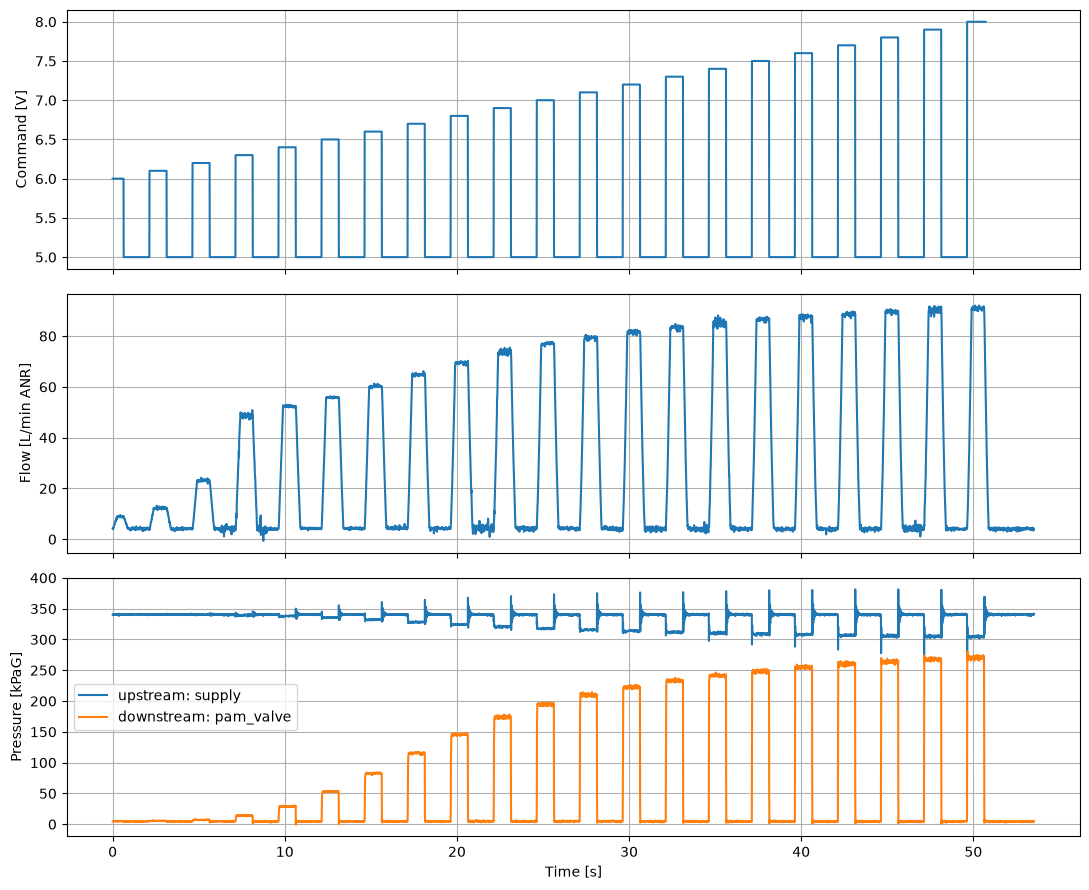

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(samples['time_s'], samples['command_voltage_v'])
axes[0].set_ylabel('Command [V]')
axes[1].plot(samples['time_s'], samples['flow_l_min_anr'])
axes[1].set_ylabel('Flow [L/min ANR]')
axes[2].plot(samples['time_s'], samples['supply_pressure_kpa_g'], label='upstream: supply')
axes[2].plot(samples['time_s'], samples['pam_valve_pressure_kpa_g'], label='downstream: pam_valve')
axes[2].set_ylabel('Pressure [kPaG]')
axes[2].set_xlabel('Time [s]')
axes[2].legend()
for axis in axes:
    axis.grid(True)
fig.tight_layout()

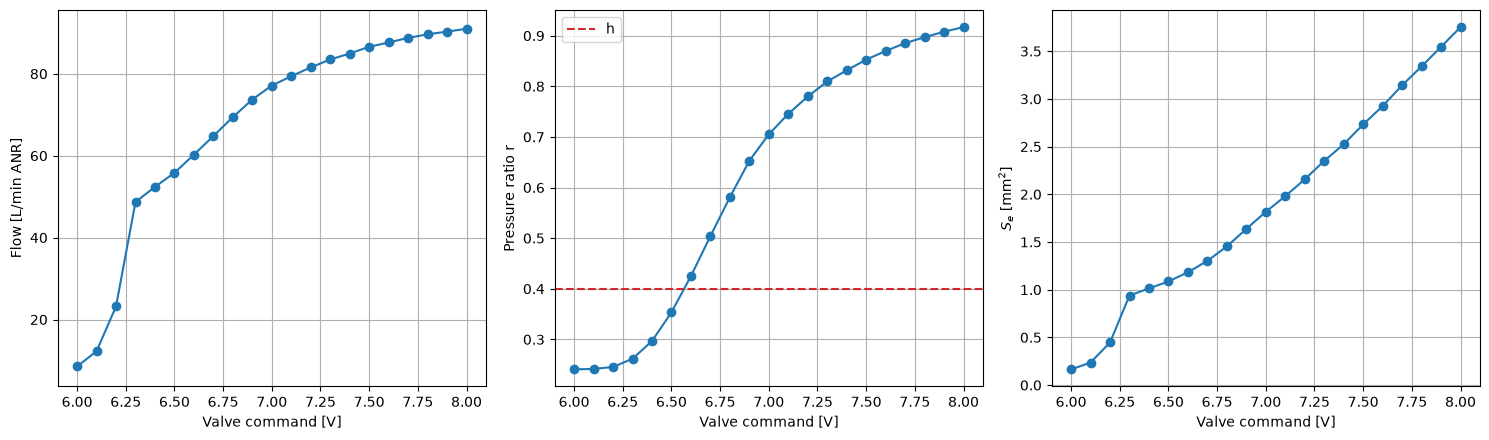

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].errorbar(result['command_voltage_v'], result['flow_l_min_anr'], yerr=result['flow_std_l_min'], marker='o')
axes[0].set_ylabel('Flow [L/min ANR]')
axes[1].plot(result['command_voltage_v'], result['pressure_ratio'], marker='o')
axes[1].axhline(config['model']['critical_pressure_ratio'], color='tab:red', linestyle='--', label='h')
axes[1].set_ylabel('Pressure ratio r')
axes[1].legend()
axes[2].plot(result['command_voltage_v'], result['effective_area_mm2'], marker='o')
axes[2].set_ylabel(r'$S_e$ [mm$^2$]')
for axis in axes:
    axis.set_xlabel('Valve command [V]')
    axis.grid(True)
fig.tight_layout()

In [27]:
problems = result.loc[
    (~result['flow_direction_ok'])
    | (~result['valid_pressure_ratio'])
    | result['flow_near_full_scale']
]
if problems.empty:
    print('No direction, pressure-ratio, or flow-range warnings.')
else:
    display(problems[columns])

No direction, pressure-ratio, or flow-range warnings.


In [28]:
# Optional CSV export
# output_path = BAG_PATH.with_name(BAG_PATH.name + '_supply_analysis.csv')
# result.to_csv(output_path, index=False)
# output_path